In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src import load_and_prep_data, run_validation_loop, HawkesModel
from src import plot_user_timeline, analyze_user_intensity, plot_parameter_distributions

In [3]:
sequences = load_and_prep_data('data/raw/retail_data.csv')

In [4]:
factory_power = lambda p: HawkesModel(baseline_model=p, penalty_weight=0.0, kernel='power')
df_results = run_validation_loop(sequences, model_factory=factory_power, label="polinomial", min_events=20)

Running 'polinomial': N=107


100%|██████████| 107/107 [00:02<00:00, 51.21it/s]


Hawkes Win Rate: 63.55%
Avg RMSE Improvement: -3.57%


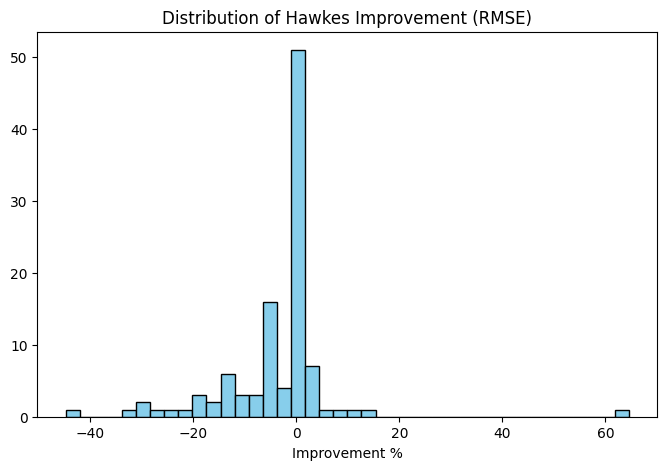

In [5]:
print(f"Hawkes Win Rate: {df_results['win_ll'].mean():.2%}")
print(f"Avg RMSE Improvement: {df_results['imp_rmse'].mean():.2f}%")

plt.figure(figsize=(8, 5))
plt.hist(df_results['imp_rmse'], bins=40, color='skyblue', edgecolor='black')
plt.title('Distribution of Hawkes Improvement (RMSE)')
plt.xlabel('Improvement %')
plt.show()

Winner ID: 12748.0 (Imp: 64.6%)
Loser ID:  15159.0 (Imp: -44.7%)


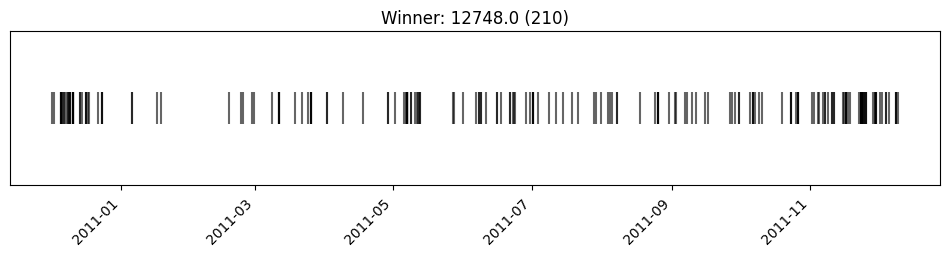

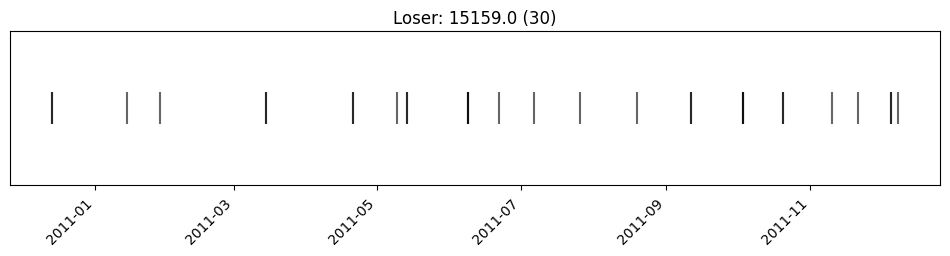

In [6]:
winners = df_results[df_results['imp_rmse'] > 10].sort_values('imp_rmse', ascending=False)
losers = df_results[df_results['imp_rmse'] < -10].sort_values('imp_rmse')

winner_id, loser_id = winners.iloc[0]['user_id'], losers.iloc[0]['user_id']

print(f"Winner ID: {winner_id} (Imp: {winners.iloc[0]['imp_rmse']:.1f}%)")
print(f"Loser ID:  {loser_id} (Imp: {losers.iloc[0]['imp_rmse']:.1f}%)")

plot_user_timeline(sequences, winner_id, title="Winner")
plot_user_timeline(sequences, loser_id, title="Loser")

/Users/amosh239/repo/mkn/Hawk's proccess/src/visualization.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grid = pd.date_range(train[0], test[-1], freq='1H')


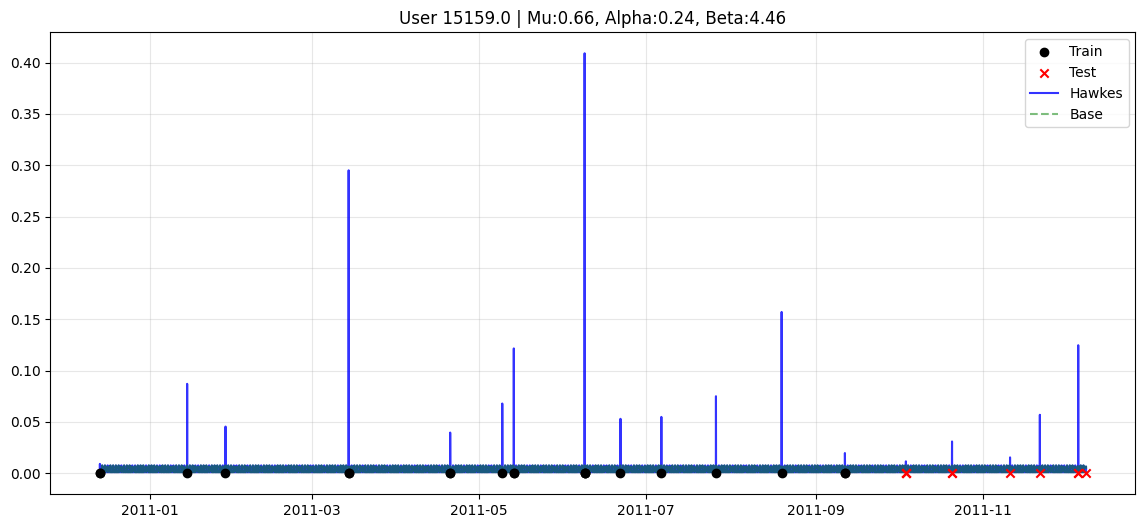

In [7]:
factory_reg = lambda p: HawkesModel(baseline_model=p, penalty_weight=50.0)
analyze_user_intensity(sequences, loser_id, factory_reg, ratio=0.8)

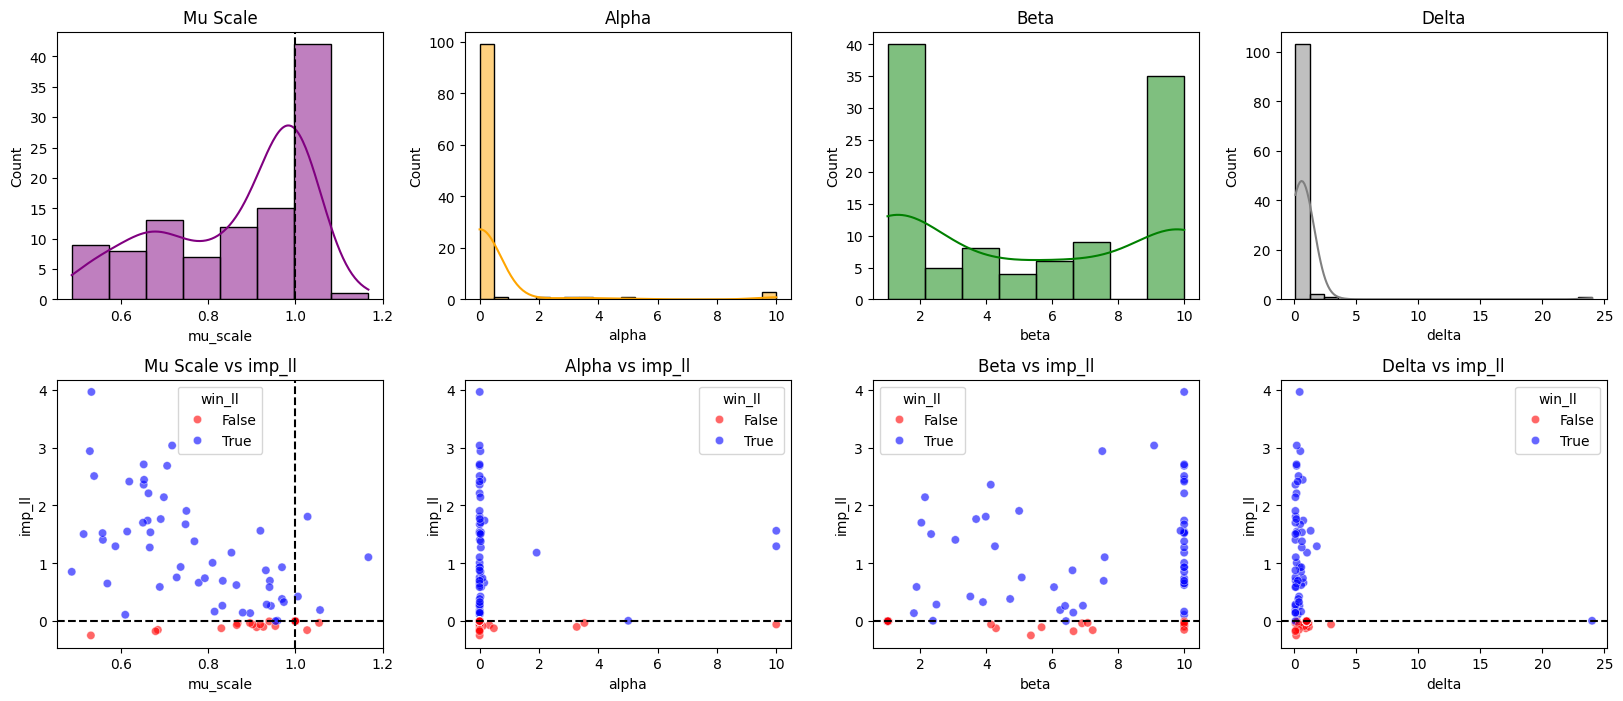

              mean       std       min       50%        max
mu_scale  0.862155  0.165282  0.487621  0.934044   1.166951
alpha     0.426050  1.772394  0.000001  0.000003  10.000000
beta      5.218263  3.846805  1.010000  4.726390  10.000000
delta     0.845981  2.306531  0.100000  0.611339  24.000000


In [8]:
plot_parameter_distributions(df_results)